## Code for calculating Beta 

In [2]:
import math
import matplotlib.pyplot as plt
import torch



In [93]:
j = torch.normal(0.0, 1/10, (10, 10, 10), dtype=torch.float64)
z,y,l = j.shape
H = j.reshape(z, -1)
H.size()
H = H - H.max(dim=1, keepdim=True).values


In [6]:
def softmax_children(X: torch.Tensor, beta: float) -> torch.Tensor:
    M = beta * X #Multiplicamos la matriz por la variable beta que regula las reglas. 
    n, a, b = M.shape #definimos n,a,b como la forma de la matriz la cual es v,v,v
    T = M.reshape(n, -1) #hacemos un reshape lo que hace que se reduzca en una dimensión la matriz lo que deja una matriz de tamaño (v,v*v)
    T = T - T.max(dim=1, keepdim=True).values #
    E = torch.exp(T)
    Z = E.sum(dim=1, keepdim=True)
    T = E / Z
    return T.reshape(n, a, b)


def joint_children(M: torch.Tensor, prior) -> torch.Tensor:
    if not torch.is_tensor(prior):
        prior = torch.tensor(prior, dtype=M.dtype, device=M.device)
    prior = prior / prior.sum()
    Pxy = torch.einsum('n,nab->ab', prior, M)
    Pxy = Pxy / Pxy.sum()
    return Pxy

def entropy(p) -> torch.Tensor:
    if not torch.is_tensor(p):
        p = torch.tensor(p, dtype=torch.float64)
    q = p.clone().reshape(-1).to(torch.float64)
    s = q.sum()
    if torch.isclose(s, torch.tensor(0.0, dtype=q.dtype)):
        raise ValueError("distribución vacía")
    q = q / s
    mask = q > 0
    return -(q[mask] * torch.log(q[mask])).sum()


def conditional_entropy_from_joint(Pxy: torch.Tensor) -> torch.Tensor:
    Px = Pxy.sum(dim=1)
    return entropy(Pxy) - entropy(Px)

In [18]:
#beta_grid = torch.arange(0.01, 25.01, 1.0, dtype=torch.float64)
beta_grid = torch.logspace(start=-1.0, end=1.0, steps=25)
vocab = [64]
n_reps = 8

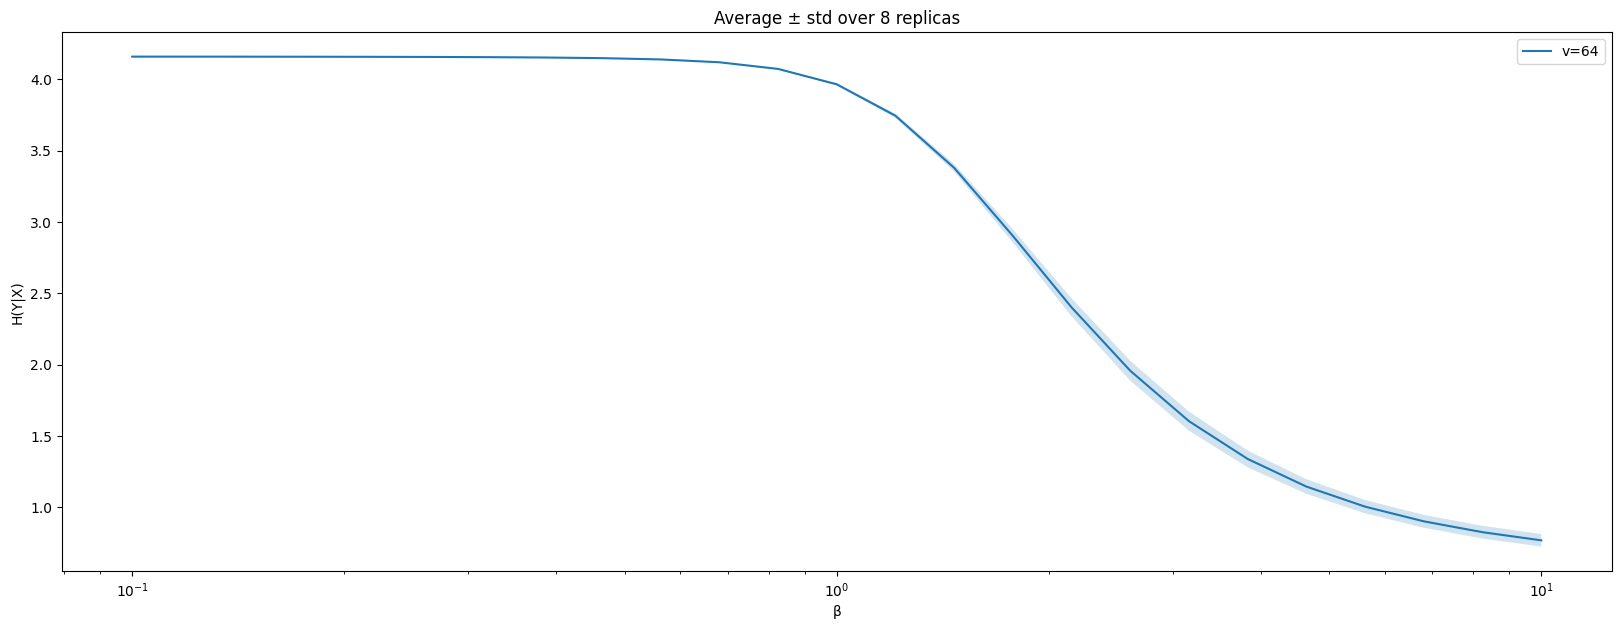

In [19]:
H_sum = {int(v): torch.zeros(len(beta_grid), dtype=torch.float64) for v in vocab}
H_sumsq = {int(v): torch.zeros(len(beta_grid), dtype=torch.float64) for v in vocab}
fig, ax = plt.subplots(figsize=(20,7))

for rep in range(1, n_reps+1):
    for v in vocab:
        sigma = math.sqrt(math.log(float(v)))
        X = torch.normal(0.0, sigma, (v, v, v), dtype=torch.float64)
        prior = torch.full((v,), 1.0 / v, dtype=torch.float64)
        H = torch.empty(len(beta_grid), dtype=torch.float64)
        for k, beta in enumerate(beta_grid.tolist()):
            M = softmax_children(X, beta)
            Pxy = joint_children(M, prior)
            H[k] = conditional_entropy_from_joint(Pxy)
        H_sum[int(v)] += H
        H_sumsq[int(v)] += H**2

H_mean = {v: H_sum[v] / n_reps for v in H_sum}
H_std  = {v: torch.sqrt(H_sumsq[v] / n_reps - H_mean[v]**2) for v in H_sumsq}

for v in vocab:
    mu = H_mean[int(v)]
    sd = H_std[int(v)]
    x = beta_grid.detach().cpu().numpy()
    ax.plot(x, mu.detach().cpu().numpy(), label=f"v={int(v)}")
    ax.fill_between(x, (mu - sd).detach().cpu().numpy(), (mu + sd).detach().cpu().numpy(), alpha=0.2)

ax.set_xlabel("β")
ax.set_ylabel("H(Y|X)")
ax.set_title(f"Average ± std over {n_reps} replicas")
ax.legend()
ax.set_xscale('log')


In [9]:
H_mean

{64: tensor([4.1586, 4.1584, 4.1582, 4.1578, 4.1572, 4.1564, 4.1549, 4.1525, 4.1480,
         4.1392, 4.1200, 4.0753, 3.9721, 3.7586, 3.3988, 2.9219, 2.4155, 1.9626,
         1.6010, 1.3300, 1.1320, 0.9880, 0.8829, 0.8055, 0.7478],
        dtype=torch.float64)}

## Marginal probability

In [58]:
v = 64 
sigma = math.sqrt(math.log(float(v)))
X = torch.normal(0.0, sigma, (v, v, v), dtype=torch.float64)
prior = torch.full((v,), 1.0 / v, dtype=torch.float64)




In [67]:
marg = entropy(torch.sum(joint_children(softmax_children(X,0.8),prior),dim=1))

marg

tensor(4.1571, dtype=torch.float64)

In [111]:
A = softmax_children(X,0.8)
T = A[4,:,:]

conditional_entropy_from_joint(T)

tensor(2.9171, dtype=torch.float64)

In [68]:
entropy(softmax_children(X,0.8))

tensor(447.1643, dtype=torch.float64)